# Markov (state-only) vs. age-dependent hazard: a quantitative comparison

This is an exploratory supplementary analysis: it checks a claim from
`pdf/manuscript_perspective.pdf` ("Old worms, new tricks: dynamical
instability explains late-life rejuvenation in C. elegans") against real
data, quantitatively rather than by eye.

## Background

The manuscript's Langevin model is **Markovian**: the rate of change of
the collective state `z` depends only on `z`'s current value, not on how
much calendar time has passed. The manuscript argues this is *why*
late-life DAF-2 depletion (the day-21 intervention) still extends
lifespan -- worms switched at day 21 behave like day-10-switched worms
once they reach the same state, regardless of the 11-day age gap. Its
Figure 2 supports this visually, with simulated trajectory insets showing
day-10 and day-21 dynamics that look indistinguishable.

"Look indistinguishable" is a visual read, not a quantitative one. This
notebook asks a more concrete, checkable question instead: does an
explicit age-dependent hazard (the classical Gompertz model) describe
the real survival data any better than our state-dependent Langevin
model does?

## What this notebook actually tests

The Markov property itself isn't something a simulation can test -- it's
a mathematical consequence of writing the drift/diffusion as functions of
`z` alone (no explicit `t`), true by construction for any parameter
values. What real data *can* test is a narrower, empirical question: does
our state-dependent model describe the observed survival curves at least
as well as a comparably-simple, purely age-dependent alternative? That
comparison is built below, in two parts:

1. **DMSO_day_10 (baseline, single phase).** Take our model's own fitted
   `(alpha, g, sigma)` for DMSO_day_10 directly from
   `0_auto_fit_parameters_mle.py` (not refit here). Fit a Gompertz hazard
   to the same data by maximum likelihood. Compare via AIC.
2. **DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention).**
   `0_auto_fit_parameters_mle.py` does not fit Auxin_day_21 at all: our
   model's phase-2 dynamics there are exactly Auxin_day_10's own
   independently-fitted parameters, reused on the reasoning that worms
   switched onto auxin at day 21 settle into the same post-auxin dynamics
   as worms given auxin at day 10. The Gompertz counterpart mirrors this
   exactly: phase 1 fixed at Part 1's own DMSO Gompertz fit, phase 2
   fixed at a Gompertz model fit to Auxin_day_10's own data (fit fresh
   here). Neither model touches Auxin_day_21's data at all -- both make a
   genuine out-of-sample prediction for that condition, so `k=0` for both
   and the comparison reduces to a direct log-likelihood comparison.

Both parts use the *same* discrete-time, grouped-data likelihood
construction for both model families (interval probability mass for
deaths, survival probability for censoring -- see `_neg_log_lik_from_S`
below), so the two hazard shapes are judged on equal footing.

## Why the Langevin model is Markovian

A stochastic process is Markovian if the distribution of its *next* step
depends only on its *current* state, not on how it got there or how much
calendar time has elapsed. Our model is `dz/dt = alpha*z + g*z^2 +
noise`, with `alpha`, `g` (`=alpha/Z`), and `sigma_sq` all *constants*
within a given phase -- the right-hand side is a function of `z` alone,
with no explicit `t` anywhere in it. Any Ito SDE `dz = b(z)dt +
sigma(z)dW` whose drift and diffusion depend only on the state defines a
time-homogeneous Markov process, by construction, so this property holds
for any parameter values -- it can't be falsified by simulation. What
data *can* speak to is whether this particular equation (rather than some
richer, `t`-dependent alternative) is an adequate description of the real
biology -- exactly the hazard-shape comparison run below.

One precise caveat about the switch: the two-phase model changes
`(alpha, g)` -- the two coefficients that actually define the drift
`dz/dt = alpha*z + g*z^2 + noise` -- at a fixed calendar day `t_switch`,
an exogenous, deterministic event (the actual day the intervention was
applied), not a hidden dependence of `z`'s own evolution on its history.
(`Z = alpha/g` and `z_m = sigma/sqrt(alpha)` are just derived quantities
of `(alpha, g, sigma)`, not independent parameters of the dynamics.)
Within each phase, conditional on which side of `t_switch` a worm is on,
the dynamics remain exactly Markovian in the sense above.

## Limitations

1. **Neither test directly validates the trajectory-level Markov claim.**
   `z` is never directly measured -- we only ever observe population
   death/censoring times. Any test built from survival data is a test of
   the *population-level hazard shape*, not of whether an individual
   worm's future genuinely depends only on its own current state.
2. **DMSO's mortality is only observed at 8 check-day ages**, with deaths
   compressed into the last four -- coarse enough that a hazard which
   plateaus *within* one of those gaps looks identical, in this data, to
   one that never plateaus. This limits how much either test's outcome
   can be over-read as evidence for or against a real late-life plateau.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution, minimize

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import kaplan_meier_curve, load_raw_survival_data
from model import km_from_fpt, simulate_fpt_and_state, simulate_two_phase

raw_data = load_raw_survival_data()
for name, d in raw_data.items():
    print(f"{name}: n={d.n_total} worms, ages {d.t.min():.0f}-{d.t.max():.0f} days")

DMSO_day_10: n=232 worms, ages 10-25 days
Auxin_day_10: n=81 worms, ages 10-42 days
Auxin_day_21: n=247 worms, ages 10-39 days


## Shared likelihood machinery

Both model families are scored with the same grouped-data log-likelihood
construction used throughout this project
(`0_auto_fit_parameters_mle.py`'s `_weighted_neg_log_lik`): each observed
death at age `t_i` contributes the model's own interval probability mass
`S(t_(i-1)) - S(t_i)` (`t_(0)=0`, `S(0)=1`); each censored worm at `t_i`
contributes the model's survival probability `S(t_i)`. The two model
families differ only in how `S` is produced -- closed-form for Gompertz,
simulated for our Langevin model -- everything else about how a
log-likelihood is built from `S` is identical, so neither model gets an
easier scoring rule than the other.

`aic`, `report_fit`, and `report_delta_aic` below are the only functions
that print/format results -- Part 1 and Part 2 both call them instead of
each formatting its own `logL`/`k`/`AIC` output, so the two parts report
identically and can't drift apart.

In [2]:
def _grouped_death_censor_weights(d):
    """(t_unique, death_weight, censor_weight) for one GroupedSurvivalData."""
    t_unique = np.unique(d.t)
    death_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight = np.array([d.weight[(d.t == t) & (d.event_observed == 0)].sum() for t in t_unique])
    return t_unique, death_weight, censor_weight


def _neg_log_lik_from_S(S_at_grid, death_weight, censor_weight, floor):
    """
    Negative grouped-data log-likelihood given S already evaluated at
    `[0, t_unique...]` (so `S_at_grid[0] == 1` by construction).
    """
    S_at_grid = np.clip(S_at_grid, floor, 1.0)
    interval_mass = np.clip(S_at_grid[:-1] - S_at_grid[1:], floor, None)
    log_lik = np.sum(death_weight * np.log(interval_mass) + censor_weight * np.log(S_at_grid[1:]))
    if not np.isfinite(log_lik):
        return np.inf
    return -float(log_lik)


def aic(logL, k):
    return 2 * k - 2 * logL


def report_fit(label, logL, k, note=""):
    """Print `label`'s logL/k/AIC in one consistent format and return its
    AIC -- used for every model/condition combination below so Part 1 and
    Part 2 report identically instead of each hand-rolling its own print."""
    suffix = f", {note}" if note else ""
    aic_val = aic(logL, k)
    print(f"{label}:  logL={logL:.4g}  (k={k}{suffix})  AIC={aic_val:.4g}")
    return aic_val


def report_delta_aic(condition, aic_gomp, aic_langevin):
    """Print + return AIC_Gompertz - AIC_Langevin for one condition, with
    the same 'favors X, |delta|>10 is decisive' framing used for every
    condition below."""
    delta = aic_gomp - aic_langevin
    print(f"\ndelta_AIC (Gompertz - Langevin), {condition} = {delta:+.4g}  "
          f"({'favors Langevin' if delta > 0 else 'favors Gompertz'}; "
          f"|delta_AIC| > 10 is conventionally read as decisive)")
    return delta

### Gompertz hazard model

Classical Gompertz hazard `M(t) = M0*exp(alpha_g*t)`, with closed-form
survival `S(t) = exp(-(M0/alpha_g)*(exp(alpha_g*t) - 1))` -- an explicit
function of calendar age, no state variable or mechanism at all.

The two-piece version does **not** restart the Gompertz clock at
`t_switch`: both `(M0_1, alpha_g1)` and `(M0_2, alpha_g2)` are always
evaluated at the worm's actual calendar age `t`, exactly as each was
fit (phase 1 against DMSO_day_10's own ages, phase 2 against
Auxin_day_10's own ages). For `t > t_switch`, phase 2's *own* survival
curve `S2(t)` is rescaled by `S1(t_switch) / S2(t_switch)` so `S` stays
continuous at the switch -- age is the shared "state" both phases refer
to, so switching hazard functions at a fixed age is the direct Gompertz
analogue of switching `(alpha, g)` at `t_switch` for a continuously
evolving `z` in the Langevin model. Resetting the clock to `t -
t_switch` instead would evaluate phase 2's curve over the wrong age
range entirely -- the near-flat, low-hazard *early* part of a curve fit
to ages 10-42, rather than the ages 21-39 actually being predicted.

In [3]:
def gompertz_survival(t, M0, alpha_g):
    t = np.asarray(t, dtype=float)
    return np.exp(-(M0 / alpha_g) * np.expm1(alpha_g * t))


def gompertz_survival_two_phase(t, M0_1, alpha_g1, M0_2, alpha_g2, t_switch):
    t = np.asarray(t, dtype=float)
    S1_at_switch = gompertz_survival(t_switch, M0_1, alpha_g1)
    S2_at_switch = gompertz_survival(t_switch, M0_2, alpha_g2)
    S = np.where(
        t <= t_switch,
        gompertz_survival(t, M0_1, alpha_g1),
        S1_at_switch * gompertz_survival(t, M0_2, alpha_g2) / S2_at_switch,
    )
    return S


def gompertz_neg_log_lik_two_phase(M0_1, alpha_g1, M0_2, alpha_g2, t_switch, d):
    """Negative log-likelihood of a *fixed* (not fit) two-phase Gompertz
    model against `d` -- the Gompertz counterpart of
    `langevin_neg_log_lik_two_phase` below, same signature shape, so Part 2
    can evaluate both model families identically."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    S = gompertz_survival_two_phase(np.concatenate(([0.0], t_unique)), M0_1, alpha_g1, M0_2, alpha_g2, t_switch)
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)


def _fit_two_stage(objective, bounds, seed):
    """Differential-evolution global search + Nelder-Mead local polish,
    the same two-stage pattern used for every fit in this project."""
    de_result = differential_evolution(objective, bounds, seed=seed, maxiter=200, popsize=20, polish=False)
    local_result = minimize(objective, x0=de_result.x, method="Nelder-Mead", bounds=bounds,
                             options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 2000})
    best_x = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_fun = min(local_result.fun, de_result.fun)
    return best_x, best_fun


def fit_gompertz_single(d, bounds, seed=0):
    """MLE fit of (M0, alpha_g) to one condition's grouped survival data."""
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)

    def objective(params):
        M0, alpha_g = params
        S = gompertz_survival(np.concatenate(([0.0], t_unique)), M0, alpha_g)
        return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

    return _fit_two_stage(objective, bounds, seed)

### Our Langevin model's own likelihood

`S` is produced by simulating `n_paths` first-passage times from the
actual model (`model.simulate_fpt_and_state`/`simulate_two_phase`, the
same `beta=1` model used everywhere else in this project) and reading
its own Kaplan-Meier curve off those simulated paths -- no closed-form
approximation, so this is correct regardless of `gamma`.

The clipping `floor` passed to `_neg_log_lik_from_S` is `1/(d.n_total +
1)` -- the real cohort size, reflecting the real data's own statistical
resolution -- so both model families are scored against the same floor.

In [4]:
def langevin_neg_log_lik_single(alpha, Z, sigma_sq, d, n_paths=20_000, dt=0.1, seed=0):
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    g = alpha / Z
    T, _, _ = simulate_fpt_and_state(
        n_paths, alpha, g, sigma_sq, Z, z0=0.0, dt=dt, t_max=t_unique[-1],
        rng=np.random.default_rng(seed),
    )
    S = km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)


def langevin_neg_log_lik_two_phase(alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, d,
                                    n_paths=20_000, dt=0.1, seed=0):
    t_unique, death_weight, censor_weight = _grouped_death_censor_weights(d)
    floor = 1.0 / (d.n_total + 1)
    T = simulate_two_phase(
        n_paths, alpha0, Z0, alpha1, Z1, sigma_sq, t_switch, t_unique[-1], dt,
        noise1=None, noise2=None,
    )
    S = km_from_fpt(T, np.concatenate(([0.0], t_unique)), t_max=t_unique[-1])
    return _neg_log_lik_from_S(S, death_weight, censor_weight, floor)

### Shared comparison plot

Part 1 and Part 2 each overlay the same three things on one axis -- the
real KM curve, the Langevin model's simulated curve, and the Gompertz
model's closed-form curve -- differing only in which condition, color,
and (for Part 2) an intervention-day marker. `plot_survival_comparison`
below draws that once, so the two parts can't silently drift out of sync
with each other.

In [5]:
def plot_survival_comparison(ax, kmf, t_plot, S_langevin, S_gompertz,
                              logL_langevin, logL_gompertz, color, title, t_switch=None):
    kmf.plot_survival_function(ax=ax, color=color, ci_show=False, label="real KM curve")
    ax.plot(t_plot, S_langevin, ls="--", color="black", label=f"Langevin model (logL={logL_langevin:.1f})")
    ax.plot(t_plot, S_gompertz, ls="-.", color="tab:red", label=f"Gompertz model (logL={logL_gompertz:.1f})")
    if t_switch is not None:
        ax.axvline(t_switch, color="gray", lw=1, ls=":", label=f"intervention start (day {t_switch:.0f})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("S(t)")
    ax.set_title(title)
    ax.legend(fontsize=8)

## Part 1: DMSO_day_10 baseline (single phase)

Our model's `(alpha, g, sigma)` are `0_auto_fit_parameters_mle.py`'s own
Step 1 fit for DMSO_day_10 (all 3 jointly estimated from this same
data, via Monte-Carlo MLE, subject to the plausibility constraints
described there) -- **not refit here**. `k=3` for the AIC below
reflects that these 3 parameters were estimated from DMSO_day_10's data,
even though we only evaluate (not re-optimize) them in this cell.

In [6]:
a0, log_g0, sigma0 = 0.1553, -2.5439, 1.5941  # 0_auto_fit_parameters_mle.py, Step 1
g0 = 10.0 ** log_g0
Z0 = a0 / g0
sigma_sq0 = sigma0 ** 2
print(f"Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha={a0}, Z={Z0:.4g}, sigma_sq={sigma_sq0:.4g}")

d_dmso = raw_data["DMSO_day_10"]

nll_langevin1 = langevin_neg_log_lik_single(a0, Z0, sigma_sq0, d_dmso, seed=0)
logL_langevin1 = -nll_langevin1
k_langevin1 = 3
aic_langevin1 = report_fit("Langevin model", logL_langevin1, k_langevin1)

bounds_gompertz1 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp1, nll_gomp1 = fit_gompertz_single(d_dmso, bounds_gompertz1, seed=0)
M0_dmso, alpha_g_dmso = popt_gomp1
logL_gomp1 = -nll_gomp1
k_gomp1 = 2
print(f"Gompertz fit: M0={M0_dmso:.4g}, alpha_g={alpha_g_dmso:.4g}")
aic_gomp1 = report_fit("Gompertz model", logL_gomp1, k_gomp1)

delta_aic1 = report_delta_aic("DMSO_day_10", aic_gomp1, aic_langevin1)

Langevin (DMSO_day_10, from 0_auto_fit_parameters_mle.py): alpha=0.1553, Z=54.33, sigma_sq=2.541
Langevin model:  logL=-408.1  (k=3)  AIC=822.1
Gompertz fit: M0=0.0004378, alpha_g=0.3336
Gompertz model:  logL=-342.9  (k=2)  AIC=689.8

delta_AIC (Gompertz - Langevin), DMSO_day_10 = -132.3  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


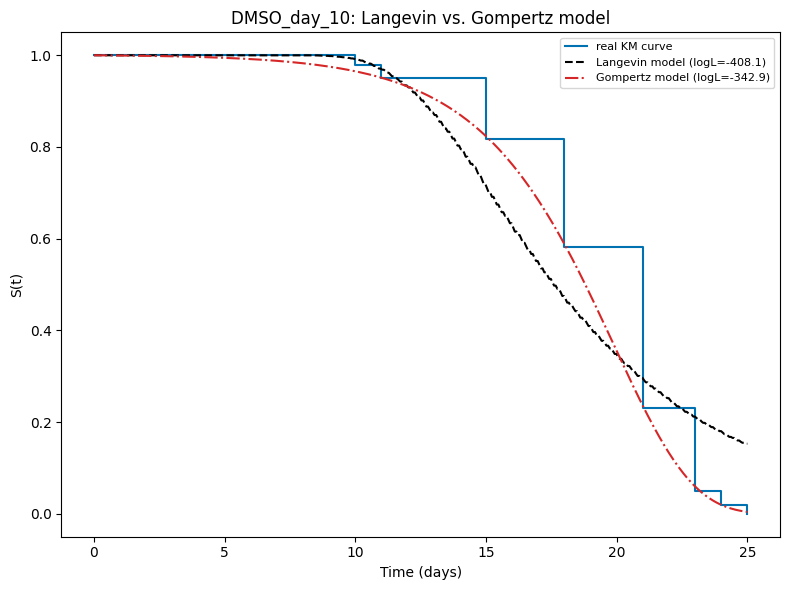

In [7]:
kmf_dmso = kaplan_meier_curve(d_dmso)
t_plot = np.linspace(0, d_dmso.t.max(), 400)
T_plot_sim1, _, _ = simulate_fpt_and_state(
    20_000, a0, g0, sigma_sq0, Z0, z0=0.0, dt=0.1, t_max=d_dmso.t.max(), rng=np.random.default_rng(1),
)
S_langevin1_plot = km_from_fpt(T_plot_sim1, t_plot, t_max=d_dmso.t.max())
S_gomp1_plot = gompertz_survival(t_plot, M0_dmso, alpha_g_dmso)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_dmso, t_plot, S_langevin1_plot, S_gomp1_plot,
                          logL_langevin1, logL_gomp1, color="#0072B2",
                          title="DMSO_day_10: Langevin vs. Gompertz model")
plt.tight_layout()
plt.show()

## Part 2: DMSO_day_10 -> Auxin_day_21 (two phase, at the intervention)

`0_auto_fit_parameters_mle.py` does not fit Auxin_day_21 at all: our
model's phase-2 dynamics there are exactly Auxin_day_10's own
independently-fitted `(a0_auxin10, log_g0_auxin10)` (Step 1b), reused on
the reasoning that worms switched onto auxin at day 21 settle into the
same post-auxin dynamics as worms given auxin at day 10.

To keep this comparison matched, the Gompertz counterpart mirrors that
construction exactly: phase 1 fixed at Part 1's own DMSO Gompertz fit,
phase 2 fixed at a Gompertz model fit to Auxin_day_10's own data (fit
fresh here, since `0_auto_fit_parameters_mle.py` only fits our Langevin
model). **Neither model touches Auxin_day_21's data at all** -- both
make a genuine out-of-sample prediction for that condition, so `k=0` for
both and the comparison reduces to a direct log-likelihood comparison.

In [8]:
a0_auxin10, log_g0_auxin10 = 0.1035, -2.7358  # 0_auto_fit_parameters_mle.py, Step 1b
g0_auxin10 = 10.0 ** log_g0_auxin10
alpha1, Z1 = a0_auxin10, a0_auxin10 / g0_auxin10
t_switch = 21.0
print(f"Langevin phase 2 (= Auxin_day_10's own fit, from 0_auto_fit_parameters_mle.py): "
      f"alpha={alpha1:.4g}, Z={Z1:.4g}")

d_auxin10 = raw_data["Auxin_day_10"]
d_auxin21 = raw_data["Auxin_day_21"]

nll_langevin2 = langevin_neg_log_lik_two_phase(a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21, seed=0)
logL_langevin2 = -nll_langevin2
k_langevin2 = 0
aic_langevin2 = report_fit("Langevin model", logL_langevin2, k_langevin2,
                            note="both phases fixed -- neither fit to Auxin_day_21")

# Gompertz counterpart: phase 2 fixed at a fresh Gompertz fit to
# Auxin_day_10's own data, mirroring Step 1b -- never touching Auxin_day_21.
bounds_gompertz_a10 = [(1e-4, 2.0), (1e-3, 2.0)]
popt_gomp_a10, nll_gomp_a10 = fit_gompertz_single(d_auxin10, bounds_gompertz_a10, seed=1)
M0_2, alpha_g2 = popt_gomp_a10
print(f"Gompertz phase 2 (Auxin_day_10, fit fresh here): M0={M0_2:.4g}, alpha_g={alpha_g2:.4g}")

nll_gomp2 = gompertz_neg_log_lik_two_phase(M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch, d_auxin21)
logL_gomp2 = -nll_gomp2
k_gomp2 = 0
aic_gomp2 = report_fit("Gompertz model", logL_gomp2, k_gomp2,
                        note="both phases fixed -- neither fit to Auxin_day_21")

delta_aic2 = report_delta_aic("Auxin_day_21", aic_gomp2, aic_langevin2)

Langevin phase 2 (= Auxin_day_10's own fit, from 0_auto_fit_parameters_mle.py): alpha=0.1035, Z=56.33
Langevin model:  logL=-460.2  (k=0, both phases fixed -- neither fit to Auxin_day_21)  AIC=920.5
Gompertz phase 2 (Auxin_day_10, fit fresh here): M0=0.001912, alpha_g=0.15
Gompertz model:  logL=-442  (k=0, both phases fixed -- neither fit to Auxin_day_21)  AIC=884

delta_AIC (Gompertz - Langevin), Auxin_day_21 = -36.52  (favors Gompertz; |delta_AIC| > 10 is conventionally read as decisive)


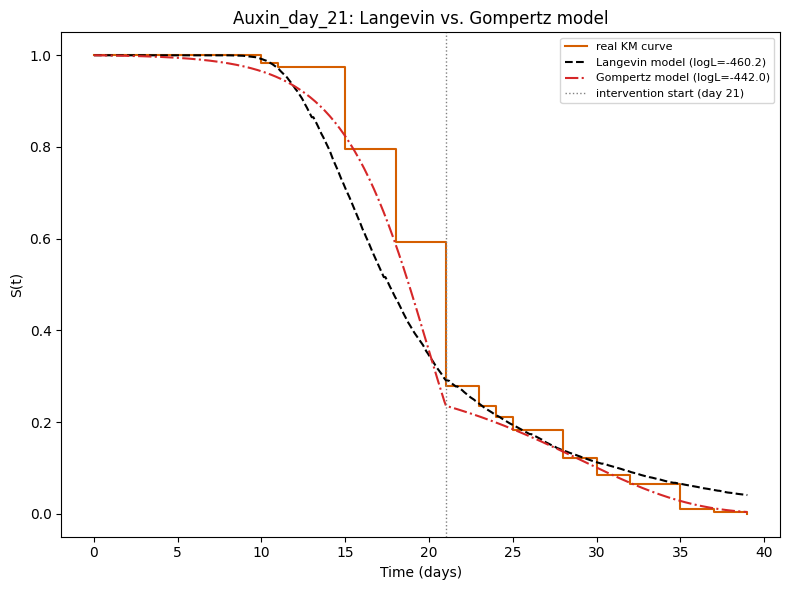

In [9]:
kmf_auxin21 = kaplan_meier_curve(d_auxin21)
t_plot21 = np.linspace(0, d_auxin21.t.max(), 400)
T_plot_sim2 = simulate_two_phase(
    20_000, a0, Z0, alpha1, Z1, sigma_sq0, t_switch, d_auxin21.t.max(), dt=0.1,
)
S_langevin2_plot = km_from_fpt(T_plot_sim2, t_plot21, t_max=d_auxin21.t.max())
S_gomp2_plot = gompertz_survival_two_phase(t_plot21, M0_dmso, alpha_g_dmso, M0_2, alpha_g2, t_switch)

fig, ax = plt.subplots(figsize=(8, 6))
plot_survival_comparison(ax, kmf_auxin21, t_plot21, S_langevin2_plot, S_gomp2_plot,
                          logL_langevin2, logL_gomp2, color="#D55E00",
                          title="Auxin_day_21: Langevin vs. Gompertz model", t_switch=t_switch)
plt.tight_layout()
plt.show()

## Summary

Report both `delta_AIC` values above plainly, whichever way they land:
a per-condition result, not a single verdict on the model. Part 1 is a
direct fit-quality comparison on DMSO_day_10's own data; Part 2 is a
genuine out-of-sample prediction test for Auxin_day_21, with both models'
phase 1 and phase 2 parameters fixed from other conditions' own fits
(DMSO_day_10, Auxin_day_10) rather than fit to Auxin_day_21 itself --
a different, arguably stronger question than Part 1's single-phase
comparison. Either way, per the limitations noted at the top: this only
ever tests the *population-level hazard shape* against calendar age, not
the trajectory-level Markov claim itself (`z` is never directly
measured), and DMSO's coarse 8 check-day resolution limits how
confidently either outcome can be read as evidence for or against a real
late-life mortality plateau.

## Manuscript-ready outputs (Supplementary Note 2)

Renders the figure and table referenced by
`notebooks/notes/supplementary_note2_model_comparison.tex`, using the
manuscript's own plotting style (`2_pub_figures_auxin10_switch.py`'s
rcParams).

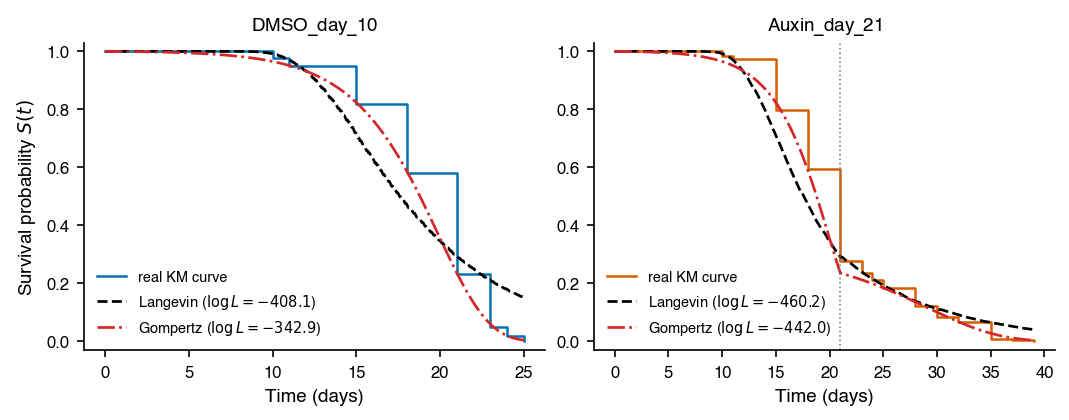

In [10]:
NOTES_DIR = NOTEBOOK_DIR / "notes"
NOTES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
})
cm = 1 / 2.54

fig_s2, axes_s2 = plt.subplots(1, 2, figsize=(18 * cm, 7 * cm))

axes_s2[0].step(kmf_dmso.survival_function_.index, kmf_dmso.survival_function_.iloc[:, 0],
                where="post", color="#0072B2", lw=1.2, label="real KM curve")
axes_s2[0].plot(t_plot, S_langevin1_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin1:.1f}$)")
axes_s2[0].plot(t_plot, S_gomp1_plot, ls="-.", color="tab:red", lw=1.3,
                 label=rf"Gompertz ($\log L={logL_gomp1:.1f}$)")
axes_s2[0].set_title("DMSO$\\_$day$\\_$10")

axes_s2[1].step(kmf_auxin21.survival_function_.index, kmf_auxin21.survival_function_.iloc[:, 0],
                where="post", color="#D55E00", lw=1.2, label="real KM curve")
axes_s2[1].plot(t_plot21, S_langevin2_plot, ls="--", color="black", lw=1.3,
                 label=rf"Langevin ($\log L={logL_langevin2:.1f}$)")
axes_s2[1].plot(t_plot21, S_gomp2_plot, ls="-.", color="tab:red", lw=1.3,
                 label=rf"Gompertz ($\log L={logL_gomp2:.1f}$)")
axes_s2[1].axvline(t_switch, color="gray", lw=0.8, ls=":")
axes_s2[1].set_title("Auxin$\\_$day$\\_$21")

for ax in axes_s2:
    ax.set_xlabel("Time (days)")
    ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="lower left")
axes_s2[0].set_ylabel("Survival probability $S(t)$")

fig_s2.tight_layout(pad=0.6)
fig_s2.savefig(NOTES_DIR / "supp_note2_fig.png", bbox_inches="tight", dpi=600)
plt.show()

In [11]:
supp2_rows = [
    {"Condition": "DMSO\\_day\\_10", "Model": "Langevin (this work)", "k": k_langevin1,
     "logL": logL_langevin1, "AIC": aic(logL_langevin1, k_langevin1)},
    {"Condition": "DMSO\\_day\\_10", "Model": "Gompertz", "k": k_gomp1,
     "logL": logL_gomp1, "AIC": aic(logL_gomp1, k_gomp1)},
    {"Condition": "Auxin\\_day\\_21", "Model": "Langevin (this work)", "k": k_langevin2,
     "logL": logL_langevin2, "AIC": aic(logL_langevin2, k_langevin2)},
    {"Condition": "Auxin\\_day\\_21", "Model": "Gompertz", "k": k_gomp2,
     "logL": logL_gomp2, "AIC": aic(logL_gomp2, k_gomp2)},
]
supp2_table = pd.DataFrame(supp2_rows).rename(columns={
    "logL": r"$\log L$", "AIC": "AIC", "k": "$k$",
})
latex_body2 = supp2_table.to_latex(index=False, escape=False, float_format="%.1f",
                                    column_format="llrrr")
latex_table2 = (
    "% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.\n"
    "\\begin{table}[htbp]\n\\centering\n"
    + latex_body2
    + "\\caption{Grouped-data maximum-likelihood fit of our Langevin model "
      "(parameters from \\texttt{0\\_auto\\_fit\\_parameters\\_mle.py}, not "
      "refit here) versus a matched-complexity Gompertz hazard, per "
      "condition. For Auxin\\_day\\_21, both models' phase 1 and phase 2 "
      "parameters are fixed from other conditions' own fits "
      "(DMSO\\_day\\_10 for phase 1, Auxin\\_day\\_10 for phase 2), so "
      "$k=0$ parameters are estimated from Auxin\\_day\\_21's own data in "
      "either model -- a genuine out-of-sample prediction, not a fit. "
      r"$\Delta\mathrm{AIC} = \mathrm{AIC}_\mathrm{Gompertz} - "
      r"\mathrm{AIC}_\mathrm{Langevin} = " + f"{delta_aic1:+.1f}"
      r"$ (DMSO\_day\_10), $" + f"{delta_aic2:+.1f}"
      r"$ (Auxin\_day\_21); negative values favor Gompertz.}"
      "\n\\label{tab:supp_note2_model_comparison}\n\\end{table}\n"
)
(NOTES_DIR / "supp_note2_table.tex").write_text(latex_table2)
print(latex_table2)

% Auto-generated by notebooks/99_markov_vs_age_dependent.py -- do not edit by hand.
\begin{table}[htbp]
\centering
\begin{tabular}{llrrr}
\toprule
Condition & Model & $k$ & $\log L$ & AIC \\
\midrule
DMSO\_day\_10 & Langevin (this work) & 3 & -408.1 & 822.1 \\
DMSO\_day\_10 & Gompertz & 2 & -342.9 & 689.8 \\
Auxin\_day\_21 & Langevin (this work) & 0 & -460.2 & 920.5 \\
Auxin\_day\_21 & Gompertz & 0 & -442.0 & 884.0 \\
\bottomrule
\end{tabular}
\caption{Grouped-data maximum-likelihood fit of our Langevin model (parameters from \texttt{0\_auto\_fit\_parameters\_mle.py}, not refit here) versus a matched-complexity Gompertz hazard, per condition. For Auxin\_day\_21, both models' phase 1 and phase 2 parameters are fixed from other conditions' own fits (DMSO\_day\_10 for phase 1, Auxin\_day\_10 for phase 2), so $k=0$ parameters are estimated from Auxin\_day\_21's own data in either model -- a genuine out-of-sample prediction, not a fit. $\Delta\mathrm{AIC} = \mathrm{AIC}_\mathrm{Gompertz} - 